Method               PSNR (dB)       SSIM
---------------------------------------------
Box k=3              27.97           0.8382
Box k=7              23.00           0.6195
Box k=15             20.70           0.4473
Gaussian s=0.5       29.26           0.7938
Gaussian s=1.5       25.38           0.7699
Gaussian s=3.0       22.36           0.5790
k=0.5 PSNR=34.45 dB
k=1.0 PSNR=28.56 dB
k=2.0 PSNR=23.00 dB
k=5.0 PSNR=16.92 dB


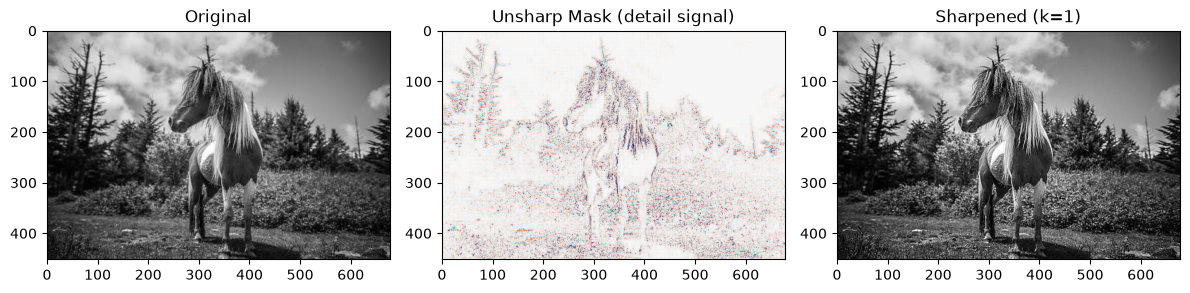

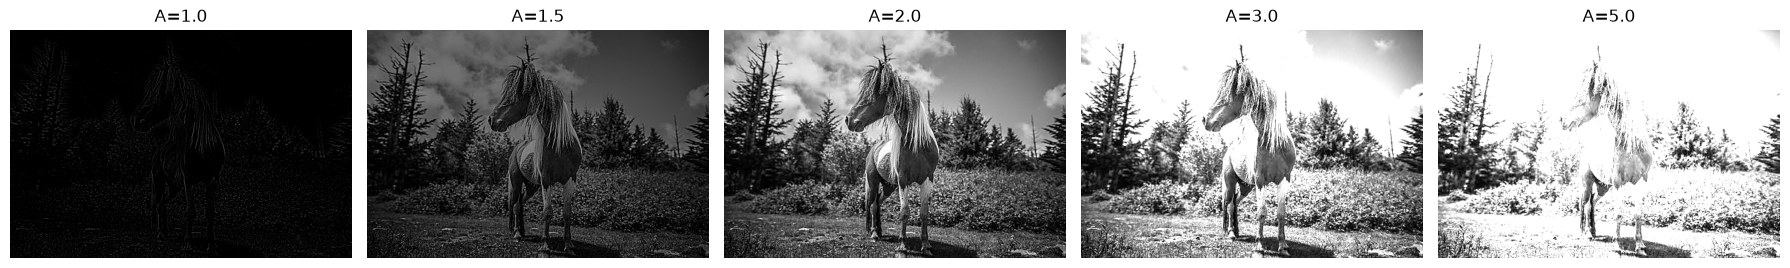

In [1]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
from scipy.ndimage import convolve, gaussian_filter
from skimage.metrics import peak_signal_noise_ratio as psnr
from skimage.metrics import structural_similarity as ssim

img = cv2.imread(r"C:\Users\X\Desktop\horse.jpg", cv2.IMREAD_GRAYSCALE)
img = img.astype(np.float64)/255.0

np.random.seed(42)
noise_sigma = 0.05
noisy = img + np.random.normal(0, noise_sigma, img.shape)
noisy = np.clip(noisy, 0, 1)

def box_filter(image, kernel_size):
    k = kernel_size
    kernel = np.ones((k, k), dtype=np.float64) / (k * k)
    return convolve(image, kernel, mode='reflect')

sizes = [3, 7, 15]
results_box = [box_filter(noisy, k) for k in sizes]

def gaussian_filter_custom(image, sigma):
    return gaussian_filter(image, sigma, mode='reflect')

sigmas = [0.5, 1.5, 3.0]
results_gauss = [gaussian_filter_custom(noisy, s) for s in sigmas]

print('Method'.ljust(20), 'PSNR (dB)'.ljust(15), 'SSIM')
print('-'* 45)
for k, r in zip(sizes, results_box):
    p = psnr(img, r, data_range=1.0)
    s = ssim(img, r, data_range=1.0)
    print(f'Box k={k}'.ljust(20), f'{p:.2f}'.ljust(15), f'{s:.4f}')

for sig, r in zip(sigmas, results_gauss):
    p = psnr(img, r, data_range=1.0)
    s = ssim(img, r, data_range=1.0)
    print(f'Gaussian s={sig}'.ljust(20), f'{p:.2f}'.ljust(15), f'{s:.4f}')

lap_4 = np.array([[0, -1, 0],
                  [-1, 4, -1],
                  [0, -1, 0]], dtype=np.float64)
lap_8 = np.array([[-1, -1, -1],
                  [-1, 8, -1],
                  [-1, -1, -1]], dtype=np.float64)

laplacian_4 = convolve(img, lap_4, mode='reflect')
laplacian_8 = convolve(img, lap_8, mode='reflect')

sharp_4 = img - laplacian_4
sharp_8 = img - laplacian_8

sharp_4 = np.clip(sharp_4, 0, 1)
sharp_8 = np.clip(sharp_8, 0, 1)

sharp_noisy_4 = np.clip(noisy - convolve(noisy, lap_4, mode='reflect'), 0, 1)

smoothed_first = gaussian_filter(noisy, sigma=1.0)
sharp_after_smooth = np.clip(smoothed_first - convolve(smoothed_first, lap_4, mode='reflect'), 0, 1)

def unsharp_mask(image, sigma, k=1.0):
    blurred = gaussian_filter(image, sigma, mode='reflect')
    mask = image - blurred
    sharpened = image + k * mask
    return np.clip(sharpened, 0, 1), mask

for sigma in [0.5, 1.0, 2.0, 4.0]:
    result, mask = unsharp_mask(img, sigma, k=1.0)

sigma_fixed = 1.0
for k in [0.5, 1.0, 2.0, 5.0]:
    result, mask = unsharp_mask(img, sigma_fixed, k=k)
    p = psnr(img, result, data_range=1.0)
    print(f'k={k} PSNR={p:.2f} dB')

result_vis, mask_vis = unsharp_mask(img, sigma=1.0, k=1.0)

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
axes[0].imshow(img, cmap='gray', vmin=0, vmax=1)
axes[0].set_title('Original')
axes[1].imshow(mask_vis, cmap='RdBu_r', vmin=-0.2, vmax=0.2)
axes[1].set_title('Unsharp Mask (detail signal)')
axes[2].imshow(img + mask_vis, cmap='gray', vmin=0, vmax=1)
axes[2].set_title('Sharpened (k=1)')
plt.tight_layout()
plt.savefig('unsharp_mask_visualisation.png', dpi=150)

def high_boost_filter(image, sigma, A):
    blurred = gaussian_filter(image, sigma, mode='reflect')
    high_boost = A * image - blurred
    return np.clip(high_boost, 0, 1)

sigma_hb = 1.5
boost_factors = [1.0, 1.5, 2.0, 3.0, 5.0]
results_hb = [high_boost_filter(img, sigma_hb, A) for A in boost_factors]

fig, axes = plt.subplots(1, len(boost_factors), figsize=(18, 4))
for ax, A, r in zip(axes, boost_factors, results_hb):
    ax.imshow(r, cmap='gray', vmin=0, vmax=1)
    ax.set_title(f'A={A}')
    ax.axis('off')
plt.tight_layout()
plt.savefig('high_boost_comparison.png', dpi=150)